In [46]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




# Initial data loading


In [47]:
#abrir grd parquet para explorar los datos y hacer un análisis de los mismos.
grd_parquet = pd.read_parquet('./grd_procesado.parquet')
#grd_parquet = pd.read_parquet('/Users/maria/Documents/Business Intelligence/W1/grd_procesado.parquet')
grd_parquet.head()  # Mostrar las primeras filas del DataFrame para explorar los datos


grd_parquet

,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
0,118100,467373,HOMBRE,1969-09-10,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
1,118100,562854,HOMBRE,1956-02-07,CONCEPCION,CORONEL,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963
2,118100,199980,MUJER,1960-02-28,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,APS CONSULTORIO (CESFAM),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
3,118100,857926,MUJER,1933-01-12,CONCEPCION,CHIGUAYANTE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,"OTRAS INSTITUCIONES SALUD (CLÍNICAS PRIVADAS, ...",URGENCIA,...,113,0.090303,0,1,0.128118,882,113,3.717488,0.476277,0.117963
4,118100,284629,HOMBRE,1951-05-03,CURICO,TENO,FONASA INSTITUCIONAL - (MAI) C,DEL MAULE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367890,111101,73167108,HOMBRE,1985-03-20,SANTIAGO,CERRILLOS,FONASA INSTITUCIONAL - (MAI) B,METROPOLITANO CENTRAL,"OTRAS INSTITUCIONES (CÁRCEL, HOGARES DE ANCIAN...",URGENCIA,...,88,0.169789,0,0,0.195122,451,88,0.76856,0.149963,0.227393
367891,118100,100641520,HOMBRE,2024-06-14,CONCEPCION,FLORIDA,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,128,0.090303,0,0,0.157248,814,128,3.394835,0.533832,0.117963
367892,116105,76585409,MUJER,1959-02-01,TALCA,TALCA,FONASA INSTITUCIONAL - (MAI) A,DEL MAULE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,155,0.123584,1,0,0.236641,655,155,2.70277,0.639587,0.157606
367893,120101,67448378,MUJER,1992-06-27,BIO-BIO,MULCHEN,FONASA INSTITUCIONAL - (MAI) B,BIOBIO,OTROS HOSPITALES DE LA RED,OBSTETRICA,...,113,0.153472,0,0,0.210037,538,113,2.404459,0.505026,0.140465


# Checking null values on the DataFrame parquet

In [48]:
#valores nulos en el parquet
grd_parquet.isnull().sum()  # Contar los valores nulos en cada columna del DataFrame parquet


COD_ESTABLECIMIENTO          0
CIP_ENCRIPTADO               0
SEXO                         0
FECHA_NACIMIENTO             0
PROVINCIA                    0
COMUNA_REGISTRADA            0
PREVISION                    0
SERVICIO_SALUD               0
TIPO_PROCEDENCIA             0
TIPO_INGRESO                 0
FECHA_INGRESO                0
FECHAALTA                    0
TIPOALTA                     0
DIAGNOSTICO1                 0
DIAGNOSTICO2                 9
DIAGNOSTICO3              4920
PROCEDIMIENTO1             127
PROCEDIMIENTO2            2329
IR_29301_COD_GRD             0
IR_29301_PESO                0
IR_29301_SEVERIDAD           0
IR_29301_MORTALIDAD          0
YEAR                         0
EDAD                         0
DIAS_ESTANCIA                0
N_COMORBILIDADES             0
N_PROCEDIMIENTOS             0
INDICE_CHARLSON              0
DESCRIPCION                  0
SECCION                      0
COD_REGION                   0
REGION                       0
ESTABLEC

# More analysis (counting men and women cases, complexity case, age)

In [49]:


df = grd_parquet.copy()  # original, never modified

print(df['COMPLEJIDAD_ESTAB'].value_counts(dropna=False))
print(df['SEXO'].value_counts(dropna=False))
print(df['EDAD'].describe())
print(df['YEAR'].value_counts().sort_index())
print(df['SEXO'].value_counts(dropna=False))
print(df['EDAD'].describe())
print(df['YEAR'].value_counts().sort_index())

COMPLEJIDAD_ESTAB
Alta Complejidad       358743
Mediana Complejidad      9152
Baja Complejidad            0
No Aplica                   0
Pendiente                   0
Name: count, dtype: int64
SEXO
HOMBRE         213422
MUJER          154431
DESCONOCIDO        42
Name: count, dtype: int64
count    367895.000000
mean         50.987017
std          26.229025
min           0.000000
25%          34.500000
50%          58.400000
75%          70.800000
max         108.200000
Name: EDAD, dtype: float64
YEAR
2019    50135
2020    54370
2021    67748
2022    61547
2023    66717
2024    67378
Name: count, dtype: int64
SEXO
HOMBRE         213422
MUJER          154431
DESCONOCIDO        42
Name: count, dtype: int64
count    367895.000000
mean         50.987017
std          26.229025
min           0.000000
25%          34.500000
50%          58.400000
75%          70.800000
max         108.200000
Name: EDAD, dtype: float64
YEAR
2019    50135
2020    54370
2021    67748
2022    61547
2023    66717


In [50]:
df.duplicated().sum()

np.int64(105)

In [51]:
dups = df[df.duplicated(keep=False)].sort_values(list(df.columns))
dups.shape[0]          # should be 210 if 105 pairs, more if some appear 3+ times
dups.head(20)

#duplicated rows to see if the diagnostic is the same or different.
dups[['CIP_ENCRIPTADO','DESCRIPCION', 'EDAD', 'SEXO', 'YEAR']].head(20)


,CIP_ENCRIPTADO,DESCRIPCION,EDAD,SEXO,YEAR
82540,612841,"COVID-19, virus identificado",63.5,MUJER,2020
83545,612841,"COVID-19, virus identificado",63.5,MUJER,2020
48828,233609,"Traumatismo del intestino delgado, con herida ...",14.8,HOMBRE,2020
90463,233609,"Traumatismo del intestino delgado, con herida ...",14.8,HOMBRE,2020
68585,397419,"Fractura del cuello de fémur, cerrada",89.6,HOMBRE,2020
72968,397419,"Fractura del cuello de fémur, cerrada",89.6,HOMBRE,2020
47221,931293,"Hemorragia intracerebral en hemisferio, cortical",53.5,HOMBRE,2020
73457,931293,"Hemorragia intracerebral en hemisferio, cortical",53.5,HOMBRE,2020
48473,1332239,"Esclerosis sistémica, no especificada",41.0,MUJER,2020
85805,1332239,"Esclerosis sistémica, no especificada",41.0,MUJER,2020


# DataFrame filtered by female gender

In [ ]:
grd_femenino = df[df['SEXO'] == 'MUJER']
grd_femenino.head()  

,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
2,118100,199980,MUJER,1960-02-28,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,APS CONSULTORIO (CESFAM),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
3,118100,857926,MUJER,1933-01-12,CONCEPCION,CHIGUAYANTE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,"OTRAS INSTITUCIONES SALUD (CLÍNICAS PRIVADAS, ...",URGENCIA,...,113,0.090303,0,1,0.128118,882,113,3.717488,0.476277,0.117963
9,116110,900702,MUJER,1947-05-10,LINARES,PARRAL,FONASA INSTITUCIONAL - (MAI) B,DEL MAULE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,0,0.135324,1,0,0.0,102,0,2.309155,0.0,0.211155
11,118100,1260221,MUJER,1959-10-19,CONCEPCION,CORONEL,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,OTROS HOSPITALES DE LA RED,URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963
13,118100,1192972,MUJER,1993-12-29,CONCEPCION,CONCEPCION,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963


# Columns of the DataFrame filtered by female gender

In [ ]:
grd_femenino.columns  

Index(['COD_ESTABLECIMIENTO', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO',
       'PROVINCIA', 'COMUNA_REGISTRADA', 'PREVISION', 'SERVICIO_SALUD',
       'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'FECHA_INGRESO', 'FECHAALTA',
       'TIPOALTA', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3',
       'PROCEDIMIENTO1', 'PROCEDIMIENTO2', 'IR_29301_COD_GRD', 'IR_29301_PESO',
       'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'YEAR', 'EDAD',
       'DIAS_ESTANCIA', 'N_COMORBILIDADES', 'N_PROCEDIMIENTOS',
       'INDICE_CHARLSON', 'DESCRIPCION', 'SECCION', 'COD_REGION', 'REGION',
       'ESTABLECIMIENTO', 'COD_COMUNA', 'COMUNA_ESTAB', 'LATITUD', 'LONGITUD',
       'PRESTADOR', 'COMPLEJIDAD_ESTAB', 'POB_COMUNA', 'POB_REGION',
       'CAMAS_TOTALES', 'CAMAS_CRITICAS', 'POB_MULT_ESTAB',
       'COMUNA_CON_ESTAB_AC', 'FALLECIDO', 'CRITICAS_PROP', 'CAMAS_COMUNA',
       'CRITICAS_COMUNA', 'CAMAS_1000HAB', 'CRITICAS_1000HAB',
       'TASA_MORTALIDAD_COMUNA'],
      dtype='str')

# Top 5 most common diagnoses in women

In [ ]:

top_diagnosticos_femeninos = (
    grd_femenino['DESCRIPCION']
    .value_counts()
    .head(5)
)
top_diagnosticos_femeninos 


DESCRIPCION
COVID-19, virus identificado                             12210
Síndrome de dificultad respiratoria del recién nacido     2982
Fractura del cuello de fémur, cerrada                     2834
Leucemia linfoblástica aguda (Todas)                      2232
Enfermedad aterosclerótica del corazón                    1920
Name: count, dtype: int64[pyarrow]

Now, we group them to see the most frequent diagnoses by year:

In [55]:
#top 5 diagnosticos mas frecuentes en mujeres por año
top_diagnosticos_femeninos_anio = (
    grd_femenino.groupby('YEAR')['DESCRIPCION'].value_counts().groupby('YEAR').head(5)
)
top_diagnosticos_femeninos_anio

YEAR  DESCRIPCION                                          
2019  Síndrome de dificultad respiratoria del recién nacido     453
      Sepsis no especificada                                    355
      Leucemia linfoblástica aguda (Todas)                      295
      Fractura del cuello de fémur, cerrada                     294
      Enfermedad aterosclerótica del corazón                    272
2020  COVID-19, virus identificado                             3465
      Síndrome de dificultad respiratoria del recién nacido     469
      Fractura del cuello de fémur, cerrada                     341
      Leucemia linfoblástica aguda (Todas)                      335
      Sepsis no especificada                                    291
2021  COVID-19, virus identificado                             7587
      Síndrome de dificultad respiratoria del recién nacido     529
      Fractura del cuello de fémur, cerrada                     423
      Leucemia linfoblástica aguda (Todas)              

# Top 5 diagnoses in women by age groups


In [ ]:
#definir rangos etarios
bins   = [18, 30, 45, 60, 75, 90, 111]
labels = ['18-29', '30-44', '45-59', '60-74', '75-89', '90+']
YEARS = range(2019, 2025)   # or range(2019, 2024)

df_clean = df.drop_duplicates().copy()
mujeres = df_clean[(df_clean['SEXO'] == 'MUJER') &
                    (df_clean['EDAD'] >= 18) &
                    (df_clean['YEAR'].isin(YEARS))].copy()
mujeres['GRUPO_ETARIO'] = pd.cut(mujeres['EDAD'], bins=bins, labels=labels, right=False)

mujeres['GRUPO_ETARIO'] = pd.cut(mujeres['EDAD'], bins=bins,
                                 labels=labels, right=False)

top_diagnosticos_femeninos_rango = (
    mujeres.groupby('GRUPO_ETARIO', observed=True)['DESCRIPCION']
    .value_counts()
    .groupby(level='GRUPO_ETARIO')
    .head(5)
)
top_diagnosticos_femeninos_rango

GRUPO_ETARIO  DESCRIPCION                                                           
18-29         COVID-19, virus identificado                                               517
              Leucemia linfoblástica aguda (Todas)                                       332
              Leucemia mieloblástica aguda (LMA)                                         159
              Embarazo tubárico                                                          108
              Benzodiazepinas                                                             78
30-44         COVID-19, virus identificado                                              1824
              Leucemia mieloblástica aguda (LMA)                                         207
              Leucemia linfoblástica aguda (Todas)                                       186
              Enfermedad renal crónica, estadio 5                                        176
              Infección consecutiva a procedimiento, no clasificada en otra pa

In [57]:
antes = df_clean[(df_clean.SEXO == 'MUJER') &
                  (df_clean.YEAR.isin(YEARS))]['DESCRIPCION'].value_counts().head(5)

despues = mujeres['DESCRIPCION'].value_counts().head(5)

print("Antes de filtrar por edad (todas las mujeres, dedup + años aplicados):")
print(antes)
print()
print("Después de filtrar por edad (>=18):")
print(despues)

Antes de filtrar por edad (todas las mujeres, dedup + años aplicados):
DESCRIPCION
COVID-19, virus identificado                             12204
Síndrome de dificultad respiratoria del recién nacido     2982
Fractura del cuello de fémur, cerrada                     2831
Leucemia linfoblástica aguda (Todas)                      2232
Enfermedad aterosclerótica del corazón                    1920
Name: count, dtype: int64[pyarrow]

Después de filtrar por edad (>=18):
DESCRIPCION
COVID-19, virus identificado              12045
Fractura del cuello de fémur, cerrada      2828
Enfermedad aterosclerótica del corazón     1920
Fractura pertrocanteriana, cerrada         1533
Sepsis no especificada                     1371
Name: count, dtype: int64[pyarrow]


# Top 5 most frequent diagnoses in adult women by year, with percentages

In [ ]:
conteo = (mujeres.groupby(['YEAR', 'DESCRIPCION'])
                 .size()
                 .rename('n')
                 .reset_index())

# denominator: all adult female discharges in that year
conteo['total_anio'] = conteo.groupby('YEAR')['n'].transform('sum')
conteo['pct'] = conteo['n'] / conteo['total_anio'] * 100

top5 = (conteo.sort_values(['YEAR', 'n'], ascending=[True, False])
              .groupby('YEAR')
              .head(5)
              .assign(rank=lambda d: d.groupby('YEAR').cumcount() + 1))

top5[['YEAR', 'rank', 'DESCRIPCION', 'n', 'pct']]



,YEAR,rank,DESCRIPCION,n,pct
1438,2019,1,Sepsis no especificada,337,1.974918
584,2019,2,"Fractura del cuello de fémur, cerrada",294,1.722925
365,2019,3,Enfermedad aterosclerótica del corazón,272,1.593999
1024,2019,4,"Neumonía, no especificada",215,1.259962
127,2019,5,Bloqueo auriculoventricular completo,212,1.242382
2033,2020,1,"COVID-19, virus identificado",3430,19.116090
2442,2020,2,"Fractura del cuello de fémur, cerrada",338,1.883743
3221,2020,3,Sepsis no especificada,286,1.593936
2230,2020,4,Enfermedad aterosclerótica del corazón,187,1.042189
2018,2020,5,Bloqueo auriculoventricular completo,179,0.997604


# Mortality and length of stay for hip fractures in women, by age group


In [ ]:
hip_codes = ['Fractura del cuello de fémur, cerrada', 'Fractura pertrocanteriana, cerrada']
hip_codes2=['S72.0', 'S72.1', 'S72.2', 'S72.3', 'S72.4', 'S72.9']
hip = mujeres[mujeres['DESCRIPCION'].isin(hip_codes)].copy()
hip2 = mujeres[mujeres['DIAGNOSTICO1'].isin(hip_codes2)].copy()

hip.groupby('GRUPO_ETARIO', observed=True).agg(
    n=('DIAS_ESTANCIA', 'size'),
    mediana_estancia=('DIAS_ESTANCIA', 'median'),
    mortalidad=('FALLECIDO', 'mean')
)



,n,mediana_estancia,mortalidad
GRUPO_ETARIO,,,
18-29,12,25.5,0.000000
30-44,17,22.0,0.058824
45-59,63,16.0,0.031746
60-74,593,15.0,0.059022
75-89,2579,14.0,0.070182
90+,1097,13.0,0.103920


# Correlation between age group and type of discharge for hip fractures in women


In [ ]:
pd.crosstab(hip['GRUPO_ETARIO'], hip['TIPOALTA'], normalize='index') * 100

TIPOALTA,ALTA VOLUNTARIA,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,DERIVACIÓN INST. PRIVADA (VOLUNTARIO),DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,DOMICILIO,FALLECIDO,FUGA DEL PACIENTE,HOSPITALIZACIÓN DOMICILIARIA
GRUPO_ETARIO,,,,,,,,,,
18-29,0.000000,0.000000,8.333333,0.000000,0.000000,8.333333,75.000000,0.000000,0.000000,8.333333
30-44,5.882353,5.882353,0.000000,5.882353,0.000000,5.882353,64.705882,5.882353,0.000000,5.882353
45-59,1.587302,1.587302,0.000000,0.000000,3.174603,7.936508,74.603175,3.174603,1.587302,6.349206
60-74,0.000000,1.349073,0.168634,0.000000,0.168634,6.408094,67.622260,5.902192,0.000000,18.381113
75-89,0.193874,2.248934,0.116324,0.038775,0.155099,5.544785,67.623110,7.018224,0.000000,17.060876
90+,0.091158,3.008204,0.000000,0.000000,0.182315,7.201459,61.713765,10.391978,0.000000,17.411121


In [61]:
hip_codes2 = ['S72.00', 'S72.01', 'S72.02',   # femoral neck, closed/open variants
              'S72.10', 'S72.11', 'S72.12',   # pertrochanteric, closed/open variants
              'S72.30', 'S72.40', 'S72.90']   # adjust once you see the full set

# safer: don't guess the full list, pull every code that actually appears
# for these two DESCRIPCION values, then generalize from there
codigos_reales = mujeres.loc[mujeres['DESCRIPCION'].isin(hip_codes), 'DIAGNOSTICO1'].unique()
print(codigos_reales)

<ArrowStringArray>
['S72.00', 'S72.10']
Length: 2, dtype: string


# Crosstab of age group vs. Charlson index tier, showing mortality rate


In [ ]:
hip.groupby('GRUPO_ETARIO', observed=True).agg(
    n=('DIAS_ESTANCIA', 'size'),
    mediana_charlson=('INDICE_CHARLSON', 'median'),
    media_charlson=('INDICE_CHARLSON', 'mean'),
    mediana_comorbilidades=('N_COMORBILIDADES', 'median'),
    media_comorbilidades=('N_COMORBILIDADES', 'mean'),
    mortalidad=('FALLECIDO', 'mean')
)
hip['CHARLSON_TIER'] = pd.cut(hip['INDICE_CHARLSON'], bins=[-1, 0, 2, 100], labels=['0', '1-2', '3+'])
pd.crosstab(hip['GRUPO_ETARIO'], hip['CHARLSON_TIER'], values=hip['FALLECIDO'], aggfunc='mean')

CHARLSON_TIER,0,1-2,3+
GRUPO_ETARIO,,,
18-29,0.000000,NaN,NaN
30-44,0.000000,0.000000,0.166667
45-59,0.000000,0.000000,0.095238
60-74,0.000000,0.059055,0.093023
75-89,0.053156,0.064337,0.094708
90+,0.061856,0.121646,0.113360


# Statistics for hip fractures in women, by age group, including Charlson index and comorbidities


In [ ]:
hip.groupby('GRUPO_ETARIO', observed=True).agg(
    n=('DIAS_ESTANCIA', 'size'),
    mediana_charlson=('INDICE_CHARLSON', 'median'),
    media_charlson=('INDICE_CHARLSON', 'mean'),
    mediana_comorbilidades=('N_COMORBILIDADES', 'median'),
    media_comorbilidades=('N_COMORBILIDADES', 'mean'),
    mortalidad=('FALLECIDO', 'mean')
)

,n,mediana_charlson,media_charlson,mediana_comorbilidades,media_comorbilidades,mortalidad
GRUPO_ETARIO,,,,,,
18-29,12,0.0,0.000000,8.0,8.666667,0.000000
30-44,17,2.0,1.705882,11.0,12.058824,0.058824
45-59,63,1.0,2.174603,7.0,9.079365,0.031746
60-74,593,2.0,2.333895,10.0,11.111298,0.059022
75-89,2579,1.0,1.887553,10.0,10.766964,0.070182
90+,1097,1.0,1.618961,10.0,10.671832,0.103920


# Top diagnoses in adult women, share of female discharges by year

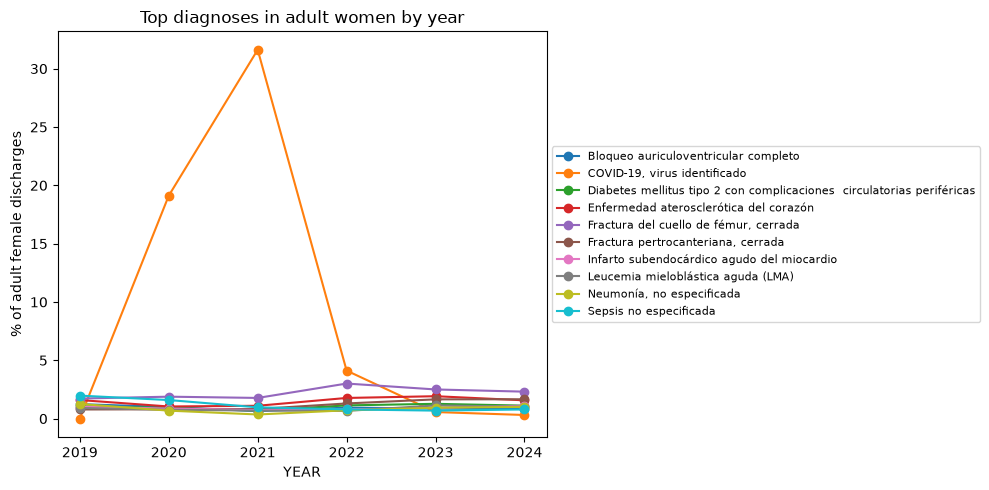

In [64]:
dx_top = top5['DESCRIPCION'].unique()

evolucion = (conteo[conteo['DESCRIPCION'].isin(dx_top)]
             .pivot(index='YEAR', columns='DESCRIPCION', values='pct'))

ax = evolucion.plot(marker='o', figsize=(10, 5))
ax.set_ylabel('% of adult female discharges')
ax.set_title('Top diagnoses in adult women by year')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

# Median length of stay and mortality for top diagnoses in women


In [ ]:
#dias de estancia para mujeres
mujeres.groupby('DESCRIPCION').agg(
    n=('DIAS_ESTANCIA', 'size'),
    mediana_estancia=('DIAS_ESTANCIA', 'median'),
    mortalidad=('FALLECIDO', 'mean')
).loc[dx_top]

,n,mediana_estancia,mortalidad
DESCRIPCION,,,
Sepsis no especificada,1371,11.0,0.617797
"Fractura del cuello de fémur, cerrada",2828,14.0,0.082390
Enfermedad aterosclerótica del corazón,1920,11.0,0.051562
"Neumonía, no especificada",1034,13.0,0.388781
Bloqueo auriculoventricular completo,1143,7.0,0.083990
"COVID-19, virus identificado",12045,19.0,0.288584
"Fractura pertrocanteriana, cerrada",1533,13.0,0.065232
Diabetes mellitus tipo 2 con complicaciones circulatorias periféricas,1311,23.0,0.135011
Leucemia mieloblástica aguda (LMA),1106,18.0,0.130199


# Female discharges by year (bars) and share of all discharges that are female (line)

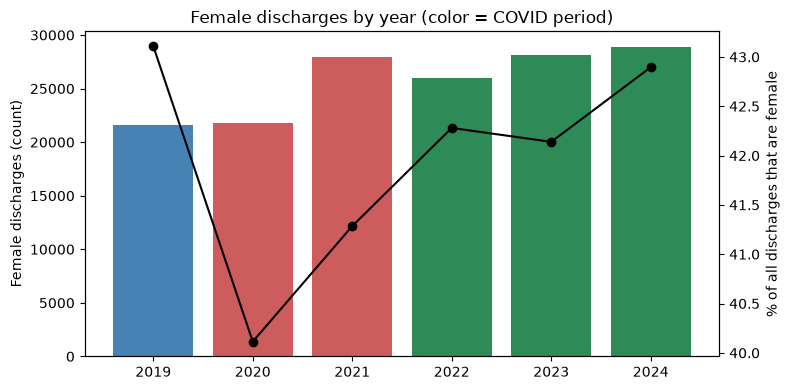

In [66]:
#Female discharges per year, with COVID periods and a denominator
def periodo(y):
    if y <= 2019: return 'Pre-COVID'
    elif y <= 2021: return 'COVID'
    else: return 'Post-COVID'

anual = df[df.YEAR.isin(YEARS)].groupby('YEAR').agg(
    total=('SEXO', 'size'),
    mujeres=('SEXO', lambda s: (s == 'MUJER').sum())
)
anual['pct_mujeres'] = anual['mujeres'] / anual['total'] * 100
anual['periodo'] = [periodo(y) for y in anual.index]

fig, ax1 = plt.subplots(figsize=(8, 4))
colors = anual['periodo'].map({'Pre-COVID': 'steelblue', 'COVID': 'indianred', 'Post-COVID': 'seagreen'})
ax1.bar(anual.index.astype(str), anual['mujeres'], color=colors)
ax1.set_ylabel('Female discharges (count)')

ax2 = ax1.twinx()
ax2.plot(anual.index.astype(str), anual['pct_mujeres'], color='black', marker='o')
ax2.set_ylabel('% of all discharges that are female')

ax1.set_title('Female discharges by year (color = COVID period)')
plt.tight_layout()
plt.show()


#  Length-of-stay (LOS) distribution and LOS by age group (adult women)

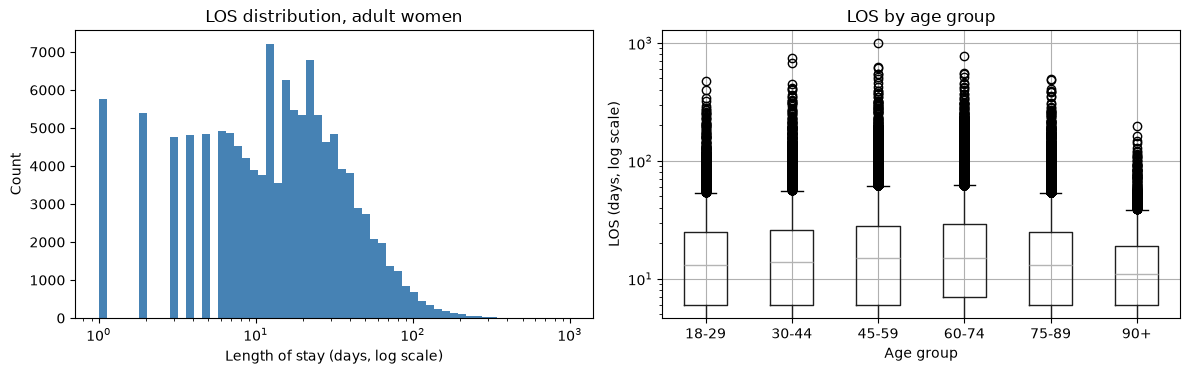

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

los_pos = mujeres.loc[mujeres['DIAS_ESTANCIA'] > 0, 'DIAS_ESTANCIA']
log_bins = np.logspace(np.log10(los_pos.min()), np.log10(los_pos.max()), 60)

axes[0].hist(los_pos, bins=log_bins, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Length of stay (days, log scale)')
axes[0].set_ylabel('Count')
axes[0].set_title('LOS distribution, adult women')

mujeres.boxplot(column='DIAS_ESTANCIA', by='GRUPO_ETARIO', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('LOS (days, log scale)')
axes[1].set_title('LOS by age group')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Diagnosis groups of median LOS vs. mortality (bubble size = n)

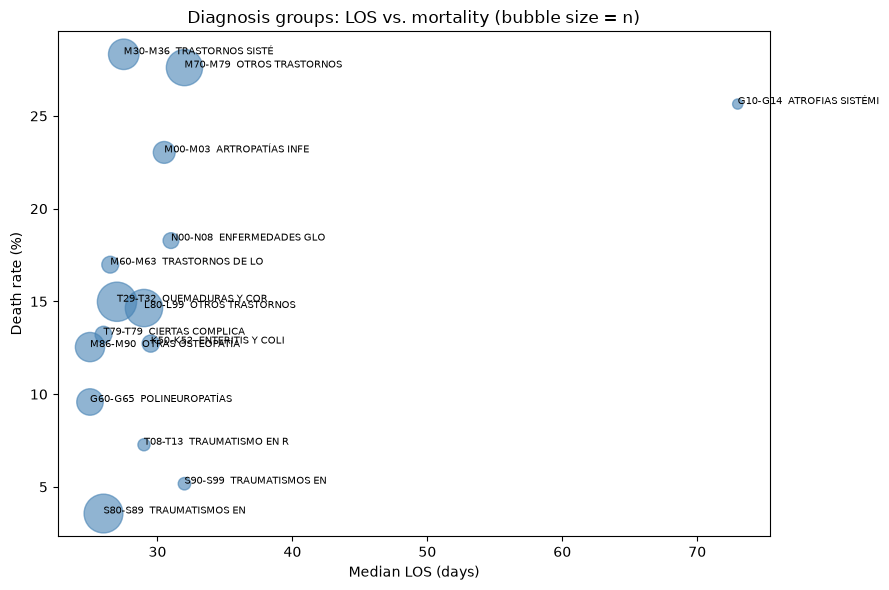

In [69]:
#Median LOS and death rate by diagnosis group, with n shown
por_seccion = mujeres.groupby('SECCION', observed=True).agg(
    n=('DIAS_ESTANCIA', 'size'),
    mediana_estancia=('DIAS_ESTANCIA', 'median'),
    mortalidad=('FALLECIDO', 'mean')
)
por_seccion = por_seccion[por_seccion['n'] >= 30].sort_values('mediana_estancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(por_seccion['mediana_estancia'], por_seccion['mortalidad'] * 100,
                     s=por_seccion['n'] / por_seccion['n'].max() * 800,
                     alpha=0.6, color='steelblue')
for name, row in por_seccion.iterrows():
    ax.annotate(name[:25], (row['mediana_estancia'], row['mortalidad'] * 100), fontsize=7)
ax.set_xlabel('Median LOS (days)')
ax.set_ylabel('Death rate (%)')
ax.set_title('Diagnosis groups: LOS vs. mortality (bubble size = n)')
plt.tight_layout()
plt.show()

# Heatmap of age group × diagnosis group


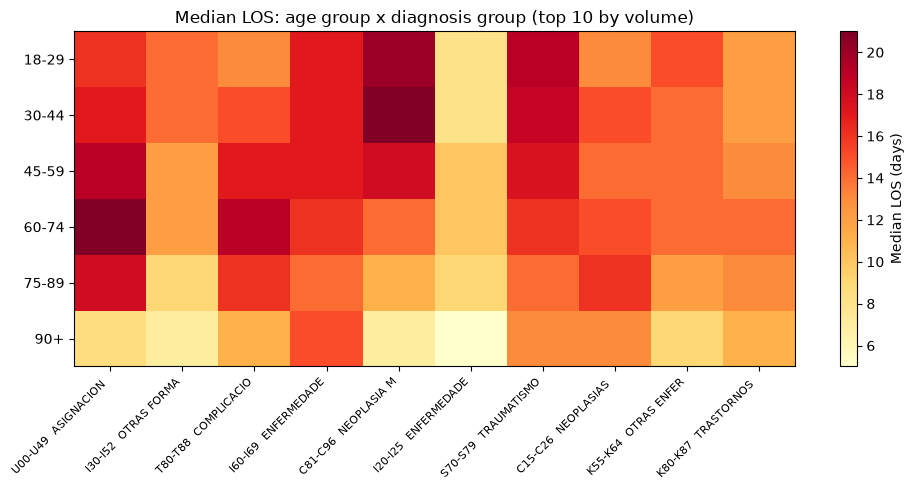

In [ ]:
top_secciones = mujeres['SECCION'].value_counts().head(10).index
sub = mujeres[mujeres['SECCION'].isin(top_secciones)]

pivot = sub.groupby(['GRUPO_ETARIO', 'SECCION'], observed=True)['DIAS_ESTANCIA'].median().unstack()
# reorder columns to match top_secciones frequency order
pivot = pivot[top_secciones]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c[:20] for c in pivot.columns], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
fig.colorbar(im, ax=ax, label='Median LOS (days)')
ax.set_title('Median LOS: age group x diagnosis group (top 10 by volume)')
plt.tight_layout()
plt.show()

# Severity level by year on adult female discharges

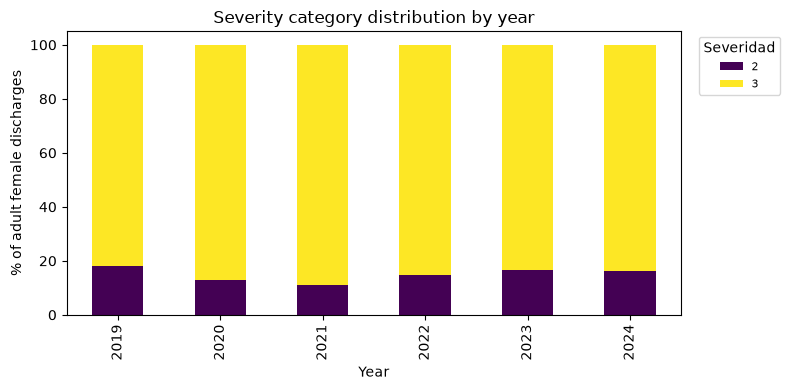

In [71]:
#IR_29301_SEVERIDAD distribution by year
sev_anual = (mujeres.groupby(['YEAR', 'IR_29301_SEVERIDAD'], observed=True)
             .size()
             .unstack()
             .apply(lambda row: row / row.sum() * 100, axis=1))

fig, ax = plt.subplots(figsize=(8, 4))
sev_anual.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_ylabel('% of adult female discharges')
ax.set_xlabel('Year')
ax.set_title('Severity category distribution by year')
ax.legend(title='Severidad', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Percentage of Women vs Men cases

In [ ]:
grd_parquet['SEXO'].value_counts(normalize=True) * 100  # Calcular el porcentaje de mujeres y hombres en el DataFrame parquet   

SEXO
HOMBRE         58.011661
MUJER          41.976923
DESCONOCIDO     0.011416
Name: proportion, dtype: float64

# Top 5 most frequent diagnoses for men

In [73]:
grd_masculino = grd_parquet[grd_parquet['SEXO'] == 'HOMBRE']
top_5_diagnosticos_masculinos = (
    grd_masculino['DESCRIPCION']
    .value_counts()
    .head(5)
)
top_5_diagnosticos_masculinos

DESCRIPCION
COVID-19, virus identificado                                              18658
Enfermedad aterosclerótica del corazón                                     6541
Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas     3985
Síndrome de dificultad respiratoria del recién nacido                      3541
Leucemia linfoblástica aguda (Todas)                                       2774
Name: count, dtype: int64[pyarrow]

# Top 5 most frequent diagnoses in men per year

In [ ]:
top_diagnosticos_masculinos_anio = (
    grd_masculino.groupby('YEAR')['DESCRIPCION'].value_counts().groupby('YEAR').head(5)
)
top_diagnosticos_masculinos_anio

YEAR  DESCRIPCION                                                           
2019  Enfermedad aterosclerótica del corazón                                      806
      Síndrome de dificultad respiratoria del recién nacido                       548
      Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas      457
      Sepsis no especificada                                                      426
      Leucemia linfoblástica aguda (Todas)                                        392
2020  COVID-19, virus identificado                                               6099
      Enfermedad aterosclerótica del corazón                                      678
      Síndrome de dificultad respiratoria del recién nacido                       540
      Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas      489
      Leucemia linfoblástica aguda (Todas)                                        426
2021  COVID-19, virus identificado                             

# Age ranges for men

In [ ]:
grd_masculino = grd_masculino.copy()

grd_masculino['EDAD'] = pd.cut(
    grd_masculino['EDAD'],
    bins=bins,
    labels=labels,
    right=False
)

top_5_diagnosticos_masculinos_rango = (
    grd_masculino.groupby('EDAD', observed=True)['DESCRIPCION']
    .value_counts()
    .groupby(level='EDAD')
    .head(5)
)
top_5_diagnosticos_masculinos_rango

EDAD   DESCRIPCION                                                                              
18-29  COVID-19, virus identificado                                                                  558
       Leucemia linfoblástica aguda (Todas)                                                          459
       Traumatismo del intestino delgado, con herida dentro de la cavidad abdominal                  231
       Traumatismo del hígado y de la vesícula biliar, con herida dentro de la cavidad abdominal     196
       Traumatismo del colon, con herida dentro de la cavidad abdominal                              168
30-44  COVID-19, virus identificado                                                                 2867
       Traumatismo del intestino delgado, con herida dentro de la cavidad abdominal                  323
       Leucemia linfoblástica aguda (Todas)                                                          263
       Infección consecutiva a procedimiento, no clasificada en

# Length of stay by sex with measures of central tendency and dispersion

In [ ]:
dias_estancia_sexo = df_clean.groupby('SEXO')['DIAS_ESTANCIA'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
dias_estancia_sexo



,mean,median,std,min,max,count
SEXO,,,,,,
DESCONOCIDO,23.571429,15.0,29.003905,0,156,42
HOMBRE,23.452631,15.0,29.974136,0,831,213357
MUJER,22.755776,15.0,29.696316,0,1266,154391


In [77]:
#cuales son los diagnosticos con mas dias de estancia asociados absolutos, tanto para hombres como para mujeres
#o sea si hay un diagnostico con 1266 dias de estancia (dia de estancia max en mujeres) y otro con 1265 dias de estancia (dia de estancia max en hombres) se debe mostrar ambos diagnosticos, aunque el diagnostico de mujeres tenga un dia mas de estancia que el de hombres.

dias_estancia_diagnosticos = (
    df_clean.groupby(['SEXO', 'DESCRIPCION'])['DIAS_ESTANCIA']
    .agg([ 'max'])
    .reset_index()
    .sort_values(by='max', ascending=False)
    .head(10)
)
dias_estancia_diagnosticos

,SEXO,DESCRIPCION,max
6289,MUJER,"Insuficiencia respiratoria aguda, Tipo no espe...",1266
5364,MUJER,Enfermedades de las neuronas motoras,992
7427,MUJER,Parálisis cerebral espástica cuadripléjica,949
6292,MUJER,"Insuficiencia respiratoria crónica, Tipo II (h...",842
2850,HOMBRE,Otras polineuropatías inflamatorias,831
2755,HOMBRE,Otras malformaciones congénitas de la tráquea,806
5272,MUJER,"Enfermedad de la médula espinal, no especificada",804
7129,MUJER,Otras obstrucciones intestinales y las no espe...,799
5061,MUJER,"Desnutrición proteicocalórica severa, no espec...",789
7176,MUJER,Otras septicemias especificadas,776


# Amount of establishments by year


In [ ]:
number_of_establishments_by_year = (
    df_clean.groupby('YEAR')['ESTABLECIMIENTO']
    .nunique()
    .reset_index()
    .rename(columns={'ESTABLECIMIENTO': 'num_establishments'})
)
number_of_establishments_by_year

,YEAR,num_establishments
0,2019,65
1,2020,65
2,2021,65
3,2022,68
4,2023,70
5,2024,72


In [79]:
n_estab = pd.Series({2019:65, 2020:65, 2021:65, 2022:68, 2023:70, 2024:72})
anual['discharges_per_estab'] = anual['mujeres'] / anual.index.map(n_estab)
print("Normalized series for discharge-per-year plot:")
print(anual[['mujeres', 'discharges_per_estab']])

Normalized series for discharge-per-year plot:
      mujeres  discharges_per_estab
YEAR                               
2019    21612            332.492308
2020    21771            334.938462
2021    27970            430.307692
2022    26022            382.676471
2023    28114            401.628571
2024    28902            401.416667


In [80]:
key_by_estab = df.groupby('COMUNA_ESTAB')['POB_COMUNA'].nunique().max()
key_by_reg   = df.groupby('COMUNA_REGISTRADA')['POB_COMUNA'].nunique().max()
print("Keyed on COMUNA_ESTAB:", key_by_estab)
print("Keyed on COMUNA_REGISTRADA:", key_by_reg)

# also check how often they differ, useful either way
pct_diff = (df['COMUNA_REGISTRADA'] != df['COMUNA_ESTAB']).mean() * 100
print(f"Registered ≠ establishment commune: {pct_diff:.1f}%")

Keyed on COMUNA_ESTAB: 6
Keyed on COMUNA_REGISTRADA: 200
Registered ≠ establishment commune: 57.2%
